In [1]:
import numpy as np, matplotlib.pyplot as plt

In [2]:
def initialize_lattice(N):
    #generating lattice(grid), of shape NxN,random magnetic moments at high entropy, either +1 or -1
    return(np.random.choice([1, -1], size = (N, N)))

In [3]:
def delta_energy(spins, i, j, J = 1):

    N = spins.shape[0]
    S = spins[i, j]

    nghbrs = (spins[(i+1) % N, j] +
              spins[(i-1)%N, j] +
              spins[i, (j+1) % N]+
              spins[i,(j-1)%N])

    #nghbrs stores the summation part in the delta Energy expression
    return(2*J*S*nghbrs)

In [ ]:
def metropolis_step(spins, T):
    #accepting the steps which lower the energy to gain stability
    #those increasing the energy are accepted with boltzmann probability
    N = spins.shape[0]

    for _ in range(N*N):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)

        dE = delta_energy(spins, i, j)

        if dE<0:
            spins[i, j] *= -1
        else:
            if np.random.rand()<np.exp(-dE/T):
                spins[i, j] *= -1


In [5]:
def run_simulation(N, T, steps):
    spins = initialize_lattice(N)
    for _ in range(steps):
        metropolis_step(spins, T)
    return(spins)

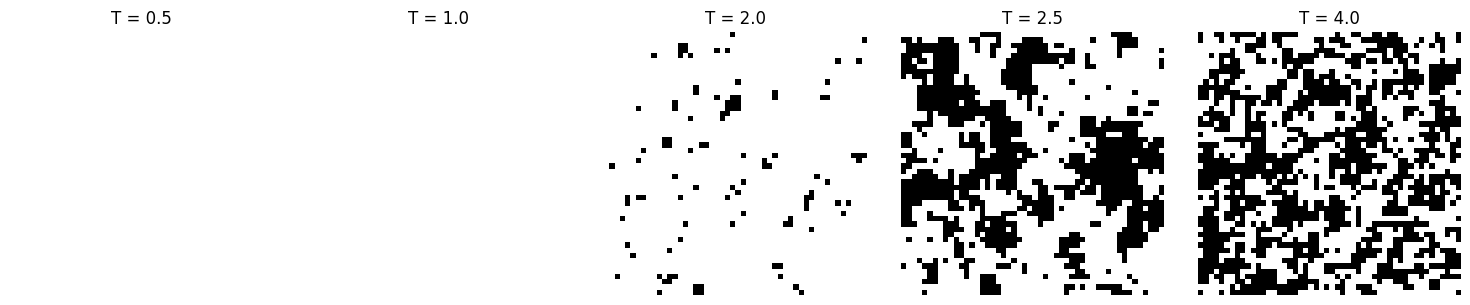

In [ ]:
N = 50  #no of rows in the sq matrix/lattice
steps = 5000
temperatures = [0.5, 1.0, 2.0, 2.5, 4.0]  #will see the patterns on these temperatures and how the pattern evolves

plt.figure(figsize = (15, 3))

for indx, T in enumerate(temperatures):
    spins = run_simulation(N, T, steps)  #gets the lattice containing the information regarding the spins

    plt.subplot(1, 5, indx+1)
    plt.imshow(spins, cmap = 'binary')
    plt.title(f"T = {T}")
    plt.axis('off')

plt.tight_layout()
plt.show()

The lattice is perfectly organized for T = 0.5 (cold) and T = 1 then slight fluctuations arise at T = 2 and more of them occur beyond that (for hot temperatures). Hence we see complete order at T = 0.5 and complete disorder at T = 4. The change starts to occur at T = 2 and is easily visible from T = 2.5

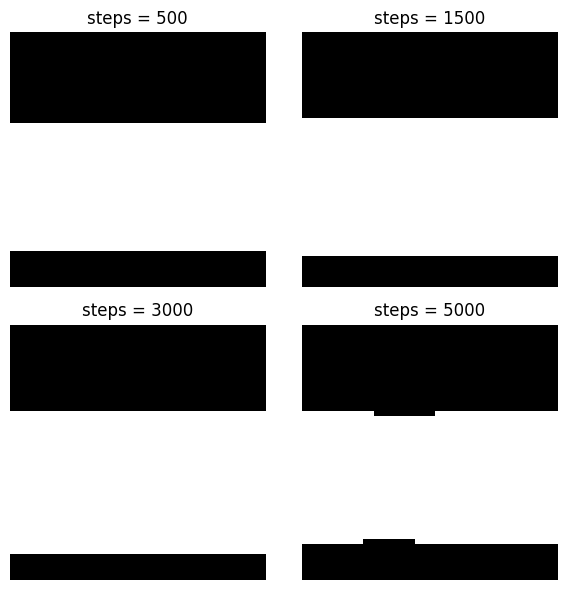

In [ ]:
T_cold = 0.5
snapshots = [500, 1500, 3000, 5000]

spins = initialize_lattice(N)
plt.figure(figsize = (6, 6))

for indx, step in enumerate(snapshots):
    for _ in range(step - (snapshots[indx - 1] if indx>0 else 0)):
        metropolis_step(spins, T_cold)

    plt.subplot(2, 2, indx+1)
    plt.imshow(spins ,cmap= 'binary')
    plt.title(f"steps = {step}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In these snapshots we don't see much of fluctuations or changes since we made it for cold temperature (T = 0.5) where patterns are dominant